# MOSAIC: Global Optimization Phase (clustering, lexicographic $\alpha \gg \beta$)

Reads `exp_global.py`'s output and plots the clustering-quality metrics
(see `src/global_opt.py`): pairwise F1 (network-wide micro-average) and ARI
(macro-averaged over mechanisms), for MOSAIC (W-2/W-3) against two
baselines: the local-IDM "no update" ablation and the naive MLE
point-estimate baseline (oracle $k$, see `cluster_1d_wcss_optimal`).

Facet grid mirrors `plot.ipynb` (the local phase): rows = ($\rho$,
$\alpha$) combinations, columns = ($E$, $S$) combinations, $N$ (sample
size) on the x-axis, so this keeps working unchanged if `conf_global.yaml`
is extended to sweep `n_clients` or `prob_shift`/`alpha` too, not just $S$
and $N$ as it currently does.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import *  # noqa
from src.mosaic import *  # noqa


In [2]:
# Read config file
config = load_config("conf_global.yaml")

# Results folder: a single one for the whole hyperparameter grid (see
# exp_global.py); each row of df_tot.csv already carries its own
# n_clients/ess/prob_shift/alpha combination.
res_path = Path(config["res_path"])

df_tot = pd.read_csv(res_path / "df_tot.csv")
# df_tot.head()


## Aggregation

Every numeric column already lives at the (hyperparameter combination x
repetition) level; group by every grid hyperparameter (not just the ones
that vary in the current `conf_global.yaml`, so this still works if the
grid is extended later) and take mean/std across repetitions.


In [3]:
group_cols = ["n_clients", "ess", "prob_shift", "alpha", "size"]
metric_cols = [c for c in df_tot.columns if c not in group_cols + ["rep"]]

agg = df_tot.groupby(group_cols)[metric_cols].agg(["mean", "std"])
agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]
df_mean = agg.reset_index()
# df_mean.head()


In [4]:
sns.reset_defaults()
plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update(
    {
        "figure.figsize": [7,4],
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "black",
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "lines.linewidth": 1.0,
        # "figure.dpi": 300,
        "savefig.dpi": 300,
        # "text.usetex": True,
    }
)


## Methods and facets

Same facet convention as the local phase's `plot.ipynb`: rows =
($\rho$, $\alpha$) combinations, columns = ($E$, $S$) combinations. $N$
(sample size) is the x-axis, since `conf_global.yaml` now sweeps it
explicitly (an exploratory sweep found MOSAIC's gain over the no-update
ablation depends on $S$ *relative to* $N$, not $S$ alone; see
`cap6_extract.tex`/`conf_global.yaml`'s own comments). Column titles show
just $S$ when `n_clients` has a single value (as now), and both $E$ and
$S$ once it is actually swept, to stay unambiguous.


In [5]:
METHODS = ("mos_w2", "mos_w3", "noupdate", "mle")
method_colors = {
    "mos_w2": "#4fc685",
    "mos_w3": "#9a97f4",
    "noupdate": "#fc9167",
    "mle": "grey",
}
method_labels = {
    "mos_w2": "MOSAIC (W-2: intersection)",
    "mos_w3": "MOSAIC (W-3: JSD-based)",
    "noupdate": "IDM",
    "mle": "MLE",
}

# Facet grid: rows = (n_clients, ess) combinations, columns =
# (prob_shift, alpha) combinations, same convention as plot_local.ipynb.
row_vals = sorted(set(df_mean[["n_clients", "ess"]].itertuples(index=False, name=None)))
col_vals = sorted(
    set(df_mean[["prob_shift", "alpha"]].itertuples(index=False, name=None))
)
print(
    f"Grid: {len(row_vals)} row(s) (n_clients, ess) x {len(col_vals)} col(s) (prob_shift, alpha)"
)

_n_clients_vals = sorted(df_mean["n_clients"].unique())


def row_label(nc, ess):
    # Show E too once n_clients is actually swept (more than one value);
    # otherwise stay as compact as the local phase's own row labels.
    return fr"$E={nc}$, $S={ess}$" if len(_n_clients_vals) > 1 else fr"$S={ess}$"


def col_label(p, a):
    # alpha is irrelevant (and deduplicated away, see exp_local.hyperparameter_combos)
    # whenever prob_shift == 0.0.
    return fr"$\rho={p}$" if p == 0 else fr"$\rho={p}$, $\alpha={a}$"


def plot_metric(metric, ylabel, ylim=None, hline=None):
    fig, axes = plt.subplots(
        len(row_vals),
        len(col_vals),
        figsize=(4.5 * len(col_vals), 3.3 * len(row_vals)),
        squeeze=False,
        sharex=True,
        sharey=True,
    )
    for i, (nc, ess) in enumerate(row_vals):
        for j, (p, a) in enumerate(col_vals):
            ax = axes[i][j]
            sub = df_mean[
                (df_mean["prob_shift"] == p)
                & (df_mean["alpha"] == a)
                & (df_mean["n_clients"] == nc)
                & (df_mean["ess"] == ess)
            ].sort_values("size")

            if hline is not None:
                ax.axhline(hline, color="gray", linewidth=0.7, linestyle=":")
            for m in METHODS:
                if m == "mle":
                    linewidth = 1.2
                    linestyle = "--"
                else:
                    linewidth = 1
                    linestyle = "-"
                mean = sub[f"{m}_{metric}_mean"]
                std = sub[f"{m}_{metric}_std"]
                ax.fill_between(
                    sub["size"], mean - std, mean + std, color=method_colors[m], alpha=0.15
                )
                ax.plot(
                    sub["size"], mean, color=method_colors[m], linewidth=linewidth, linestyle=linestyle, label=method_labels[m]
                )

            if i == 0:
                ax.set_title(col_label(p, a), fontsize=9)
            if j == 0:
                ax.set_ylabel(f"{row_label(nc, ess)}\n{ylabel}", fontsize=8)
            if i == len(row_vals) - 1:
                ax.set_xlabel("$N$")
            if ylim:
                ax.set_ylim(*ylim)

    axes[0][-1].legend(loc="best", fontsize=6)
    plt.tight_layout()
    return fig


Grid: 3 row(s) (n_clients, ess) x 2 col(s) (prob_shift, alpha)


## Grafico 1: pairwise F1 (network-wide, micro-averaged)

Every client pair, of every mechanism $(X, \pi_X)$, in one repetition is
pooled into a single confusion matrix before computing precision/recall/F1
(see `src/global_opt.py::pairwise_confusion`): the natural aggregation
here, since P/R/F1 are properties of individual client pairs and every
mechanism contributes the same number of pairs. Band is mean $\pm$ 1 std
**across repetitions**.


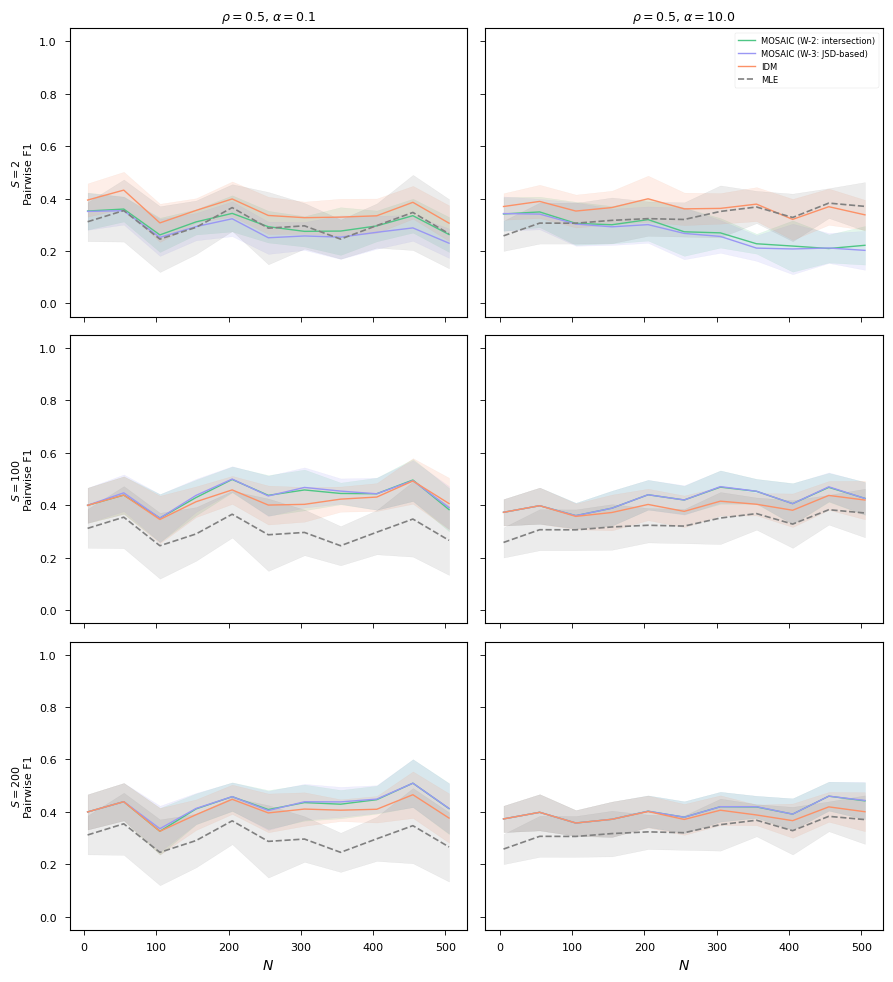

In [6]:
fig = plot_metric("f1", "Pairwise F1", ylim=(-0.05, 1.05))
plt.show()
fig.savefig(f"{res_path}_f1.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Grafico 1.1: precision (network-wide, micro-averaged)

Of all the client pairs a method declared *same* (same mechanism), what
fraction really are (pooled across every mechanism, same micro-averaging as
F1; see `src/global_opt.py::pairwise_confusion`). Low precision means the
method over-merges: it fuses clients that are actually different. Same
mean $\pm$ 1 std band across repetitions as the other network-wide plots.


In [7]:
# fig = plot_metric("precision", "Precision", ylim=(-0.05, 1.05))
# plt.show()
# fig.savefig(f"{res_path}_precision.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Grafico 1.2: recall (network-wide, micro-averaged)

Of all the client pairs that really *are* the same, what fraction a method
correctly found (same pooling as precision/F1). Low recall means the
method is too conservative/fragmented: it keeps apart clients that
actually share the same mechanism. Precision and recall together explain
F1's movements, e.g. a case already found in the per-CPT section, where
low-$S$ MOSAIC's more plausible-looking cluster count did NOT mean better
clustering: both its precision AND recall were worse than the no-update
ablation's there.


In [8]:
# fig = plot_metric("recall", "Recall", ylim=(-0.05, 1.05))
# plt.show()
# fig.savefig(f"{res_path}_recall.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Grafico 2: Adjusted Rand Index (macro-averaged over mechanisms)

Unlike F1, ARI compares two *partitions* of the same client set, so it
cannot be pooled across mechanisms (each mechanism has its own true
partition): computed per mechanism, then macro-averaged (plain mean) across
the network's mechanisms (see `src/global_opt.py::ari_ami`), then, as
always, mean $\pm$ std across repetitions.


In [9]:
# fig = plot_metric("ari", "ARI")
# plt.show()
# fig.savefig(f"{res_path}_ari.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Grafico 2.1: Adjusted Mutual Information (macro-averaged over mechanisms)

Same aggregation as ARI (per-mechanism, then macro-averaged, since, like
ARI, it compares two *partitions* of the same client set and so cannot
be pooled across mechanisms): computed via `src/global_opt.py::ari_ami`,
then mean $\pm$ std across repetitions, same as every other network-wide
plot. Unlike ARI (a pair-counting measure), AMI is information-theoretic
(based on mutual information between the two partitions, adjusted for
chance); the two usually agree, but AMI is less sensitive to the skewed
cluster-size distributions this task tends to produce (one large
mask-preserving cluster plus several singletons), where ARI is known to
behave less intuitively, so it is worth checking side by side with ARI
rather than assuming they always tell the same story.


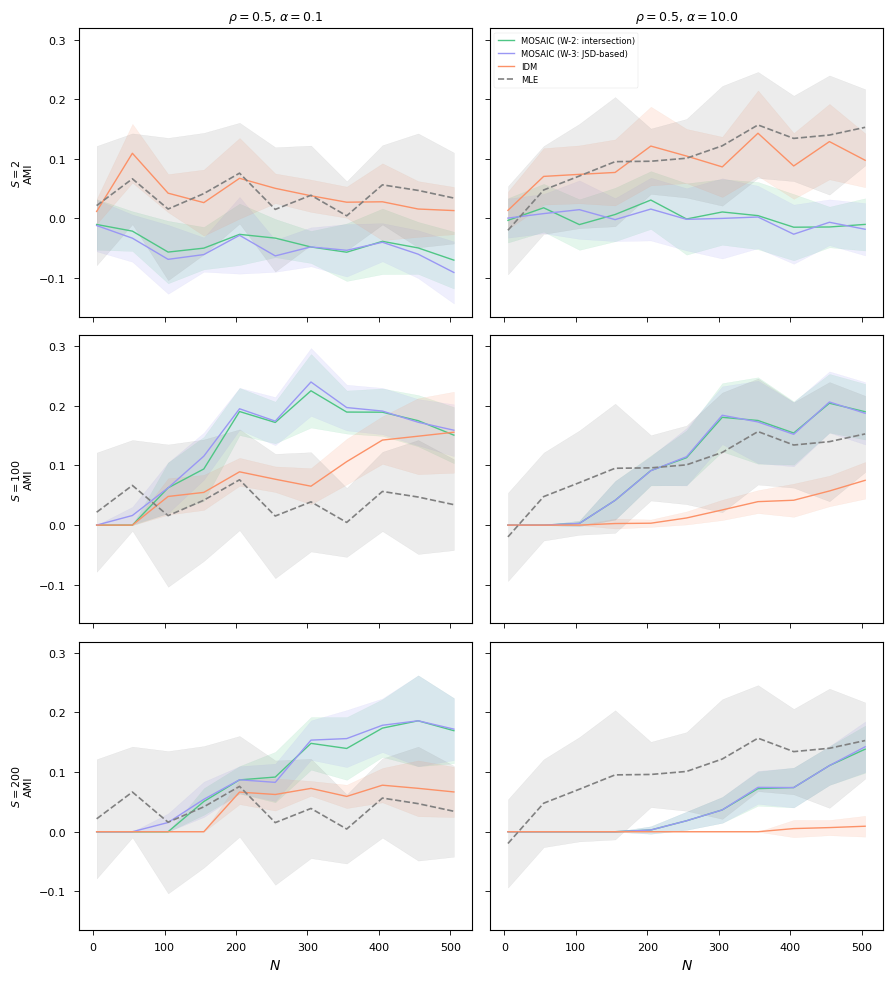

In [10]:
fig = plot_metric("ami", "AMI")
plt.show()
fig.savefig(f"{res_path}_ami.svg", dpi=1200, bbox_inches="tight", transparent=False)


## Grafico 3: mean number of clusters found (diagnostic)

Not a headline accuracy metric, but a useful diagnostic for *why* F1/ARI
move the way they do: how many clusters each method finds, network-wide,
versus the true mean cluster count (dashed). `mle`'s baseline is handed the
true cluster count as an oracle (`cluster_mle_gaps`, see `src/global_opt.py`
-- deliberately conservative, i.e. an advantage MOSAIC does NOT get), so its
curve sits exactly on top of "True" by construction; it is shown mainly as
a visual anchor for the other three methods, which get no such help.


/tmp/ipykernel_183936/2125263716.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(sub["size"], true_mean, "k--", label="True", linewidth=1.2, color="grey")


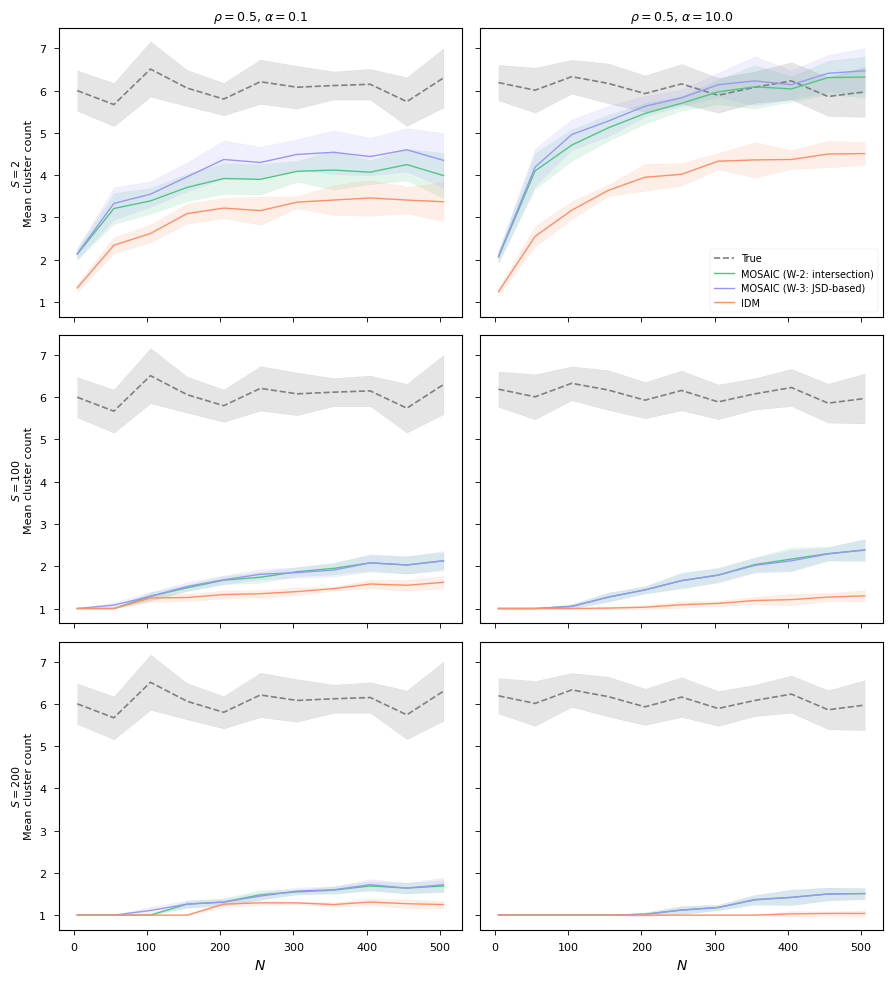

In [11]:
fig, axes = plt.subplots(
    len(row_vals),
    len(col_vals),
    figsize=(4.5 * len(col_vals), 3.3 * len(row_vals)),
    squeeze=False,
    sharex=True,
    sharey=True,
)
for i, (nc, ess) in enumerate(row_vals):
    for j, (p, a) in enumerate(col_vals):
        ax = axes[i][j]
        sub = df_mean[
            (df_mean["prob_shift"] == p)
            & (df_mean["alpha"] == a)
            & (df_mean["n_clients"] == nc)
            & (df_mean["ess"] == ess)
        ].sort_values("size")

        true_mean = sub["n_clusters_true_mean_mean"]
        true_std = sub["n_clusters_true_mean_std"]
        ax.fill_between(sub["size"], true_mean - true_std, true_mean + true_std, color="black", alpha=0.1)
        ax.plot(sub["size"], true_mean, "k--", label="True", linewidth=1.2, color="grey")
        for m in METHODS:
            if m == "mle":
                continue
            mean = sub[f"{m}_n_clusters_mean_mean"]
            std = sub[f"{m}_n_clusters_mean_std"]
            ax.fill_between(sub["size"], mean - std, mean + std, color=method_colors[m], alpha=0.15)
            ax.plot(
                sub["size"],
                mean,
                color=method_colors[m],
                label=method_labels[m],
                linewidth=1,
                linestyle="-"
            )

        if i == 0:
            ax.set_title(col_label(p, a), fontsize=9)
        if j == 0:
            ax.set_ylabel(f"{row_label(nc, ess)}\nMean cluster count", fontsize=8)
        if i == len(row_vals) - 1:
            ax.set_xlabel("$N$")

axes[0][-1].legend(fontsize=7)
plt.tight_layout()
plt.show()
fig.savefig(f"{res_path}_nclusters.svg", dpi=1200, bbox_inches="tight", transparent=False)
